### Weather prediction - binary classification

In [ ]:
import pandas as pd
import numpy as np
from numpy.typing import NDArray
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay

In [2]:
# Zadanie 1
# a)
weather_df: pd.Dataframe = pd.read_csv("weather_Portland.csv")
# b)
cols_to_drop = ["Date", "Location", "Evaporation", "Sunshine", "RainToday", "RISK_MM"]
weather_df = weather_df.drop(columns=cols_to_drop)
# c)
weather_df = weather_df.dropna(subset=["RainTomorrow"])
# d)
weather_df = weather_df[weather_df.isna().sum(axis=1) < 3]

In [3]:
# Zadanie 2
# a)
numerical_cols = weather_df.select_dtypes(include=np.number).columns
categorical_cols = weather_df.select_dtypes(include="str").columns

medians = weather_df[numerical_cols].median()
weather_df[numerical_cols] = weather_df[numerical_cols].fillna(medians)

most_frequent_cat_values_per_col = weather_df[categorical_cols].mode(axis=0, dropna=True).iloc[0]
weather_df[categorical_cols] = weather_df[categorical_cols].fillna(most_frequent_cat_values_per_col)

# b)
pressure_cols = ["Pressure9am", "Pressure3pm"]
pressure_categories = ["bardzo_niskie", "niskie", "normalne", "wysokie", "bardzo_wysokie"]
def create_pressure_bins(pressure_col:  pd.Series, labels: list[str]) -> pd.Series:
    pressure_bins = [-np.inf, 980, 1000, 1020, 1040, np.inf]
    
    return pd.cut(pressure_col, bins=pressure_bins, labels=labels)

weather_df[pressure_cols] = weather_df[pressure_cols].apply(lambda col: create_pressure_bins(pressure_col=col, labels=pressure_categories))


In [4]:
# Zadanie 3
# a)
X: pd.DataFrame = weather_df.drop(columns=["RainTomorrow"])
y: pd.Series = weather_df["RainTomorrow"]

# b)
numerical_cols = X.select_dtypes(include=np.number).columns
stds = X[numerical_cols].std(axis=0)
means = X[numerical_cols].mean(axis=0)

X[numerical_cols] = X[numerical_cols].clip(
    lower=means - 3 * stds,
    upper=means + 3 * stds,
    axis=1
)

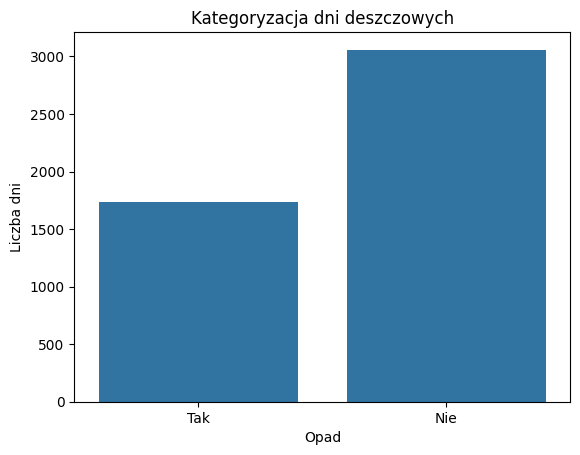

In [5]:
# Zadanie 4
y = y.replace({"Yes": "Tak", "No": "Nie"})
plot = sns.countplot(x=y)
plot.set_xlabel("Opad")
plot.set_ylabel("Liczba dni")
plot.set_title("Kategoryzacja dni deszczowych")
plt.show()


In [6]:
# Zadanie 5
# a) Ordinal categorical columns: hierarchical ranked data
ordinal_categories = [pressure_categories]*len(pressure_cols) # Correct shape for n_features in OrdinalEncoder, pass as many lists of categories as there is ordinal columns we want to transform
ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)
ordinal_cat_features = X[pressure_cols].astype(dtype="str") # Change cols from Category type to str for ordinal_encoder compatibility
ordinal_cat_features_encoded = ordinal_encoder.fit_transform(ordinal_cat_features)
X[pressure_cols] = ordinal_cat_features_encoded

# b) Nominal categorical columns - not ordered by any means
nominal_cat_cols = ["WindGustDir", "WindDir9am", "WindDir3pm"]
one_hot_encoder = OneHotEncoder(drop="first", sparse_output=False)
nominal_cat_features_1hot_encoded = one_hot_encoder.fit_transform(X[nominal_cat_cols])
nominal_cat_encoded = pd.DataFrame(nominal_cat_features_1hot_encoded, columns=one_hot_encoder.get_feature_names_out(nominal_cat_cols))

X = X.drop(labels=nominal_cat_cols, axis=1)
X = X.reset_index(drop=True)
X = pd.concat([X, nominal_cat_encoded], axis=1)

# c) 
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# d) features normalization
feature_range = (0, 1)
scaler = MinMaxScaler(feature_range=feature_range)
# Explicitly provide all numerical columns to normalize except for ordinal and hot-one encoded ones
num_cols = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 
    'WindSpeed9am','WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 
    'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm'
]
X_num_cols_normalized = scaler.fit_transform(X[num_cols])
X[num_cols] = X_num_cols_normalized


['Nie' 'Tak']


In [7]:
# Zadanie 6
# a)
X_arr = X.to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X_arr, y, test_size=0.2, random_state=42)

# b) & c)
class ModelHandler:
    def __init__(self, model: BaseEstimator):
        self.model: BaseEstimator = model
        self.model_name: str = self.get_model_name()
        self.y_train_pred: NDArray | None = None
        self.y_test_pred: NDArray | None = None

    def get_model_name(self) -> str:
        if isinstance(self.model, SVC):
            return f"{type(self.model).__name__}_{self.model.kernel}"
        else:
            return type(self.model).__name__
   
    def train_and_predict(self, X_train: NDArray, y_train: NDArray, X_test: NDArray) -> None:
        self.model.fit(X_train, y_train)
        self.y_train_pred = self.model.predict(X=X_train)
        self.y_test_pred = self.model.predict(X=X_test)
    
    def compute_model_metrics(self, y_true_train: NDArray, y_true_test: NDArray) -> dict:
        if self.y_train_pred is not None and self.y_test_pred is not None:
            return {
                "acc_train": accuracy_score(y_true=y_true_train, y_pred=self.y_train_pred),
                "acc_test": accuracy_score(y_true=y_true_test, y_pred=self.y_test_pred),
                "prc_train": precision_score(y_true=y_true_train, y_pred=self.y_train_pred),
                "prc_test": precision_score(y_true=y_true_test, y_pred=self.y_test_pred),
                "rcl_train": recall_score(y_true=y_true_train, y_pred=self.y_train_pred),
                "rcl_test": recall_score(y_true=y_true_test, y_pred=self.y_test_pred),
            }
        else:
            raise ValueError("Cannot compute metrics, model did not make any predictions")

# init every classifier from exercise
classifiers: list[BaseEstimator] = [KNeighborsClassifier(), DecisionTreeClassifier(max_depth=4), LogisticRegression(), SVC(kernel="linear", C=3), SVC(kernel="rbf", gamma="scale", C=1)]
# Untrained initialized models capsulated into handler class
model_handlers: dict[str, ModelHandler] = {
    (handler := ModelHandler(classifier)).model_name: handler for classifier in classifiers
}

# train each model and make train set and test set predictions
for model in model_handlers.values():
    model.train_and_predict(X_train=X_train, y_train=y_train, X_test=X_test)

In [8]:
# Zadanie 7 
# a) & b) 
df_data = [
    {"model_name": model_name, **model.compute_model_metrics(y_true_train=y_train, y_true_test=y_test)} for model_name, model in model_handlers.items()
]
df_metrics = pd.DataFrame(data=df_data).set_index("model_name")
df_metrics.index.name = None

df_metrics

,acc_train,acc_test,prc_train,prc_test,rcl_train,rcl_test
KNeighborsClassifier,0.820981,0.731733,0.795110,0.655052,0.680375,0.543353
DecisionTreeClassifier,0.784969,0.783925,0.791494,0.779116,0.550505,0.560694
LogisticRegression,0.793319,0.810021,0.752122,0.778912,0.639250,0.661850
SVC_linear,0.795407,0.816284,0.755952,0.795139,0.641414,0.661850
SVC_rbf,0.808716,0.806889,0.778346,0.778547,0.658730,0.650289


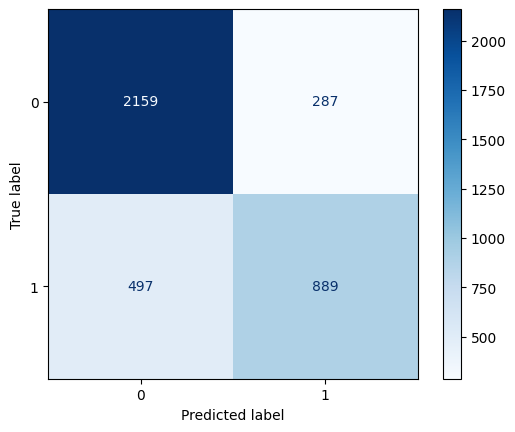

In [9]:
# c)
best_test_acc_model = model_handlers[df_metrics['acc_test'].idxmax()]

cm_train_set = confusion_matrix(y_true=y_train, y_pred=best_test_acc_model.y_train_pred)
disp_train_cm = ConfusionMatrixDisplay(cm_train_set)
disp_train_cm.plot(cmap="Blues")

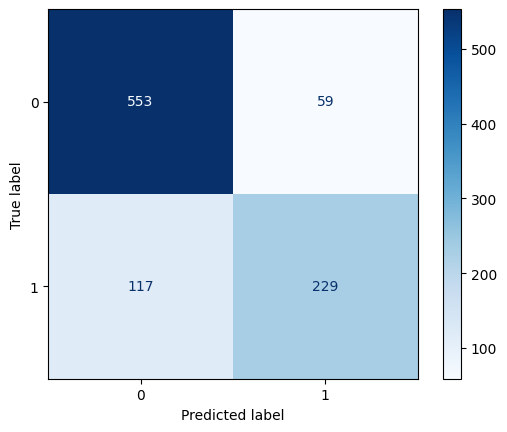

In [10]:
cm_test_set = confusion_matrix(y_true=y_test, y_pred=best_test_acc_model.y_test_pred)
disp_test_cm = ConfusionMatrixDisplay(cm_test_set)
disp_test_cm.plot(cmap="Blues")

In [ ]:
# d)
# ROC curve for decision tree on train set
dt_clf = model_handlers["DecisionTreeClassifier"].model
dt_y_train_scores = dt_clf.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, dt_y_train_scores)
roc_auc = auc(fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, name="DecisionTreeClassifier").plot()

In [ ]:
# ROC curve for decision tree on test set
dt_y_test_scores = dt_clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, dt_y_test_scores)
roc_auc = auc(fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, name="DecisionTreeClassifier").plot()

In [ ]:
# ROC curve for logistic regression on train set
lr_clf = model_handlers["LogisticRegression"].model
lr_y_train_scores = lr_clf.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, lr_y_train_scores)
roc_auc = auc(fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, name="LogisticRegression").plot()

In [ ]:
# ROC curve for logistic regression on test set
lr_y_test_scores = lr_clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, lr_y_test_scores)
roc_auc = auc(fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, name="LogisticRegression").plot()